 # MATHEMATICS FOR COMPUTING - 3

PROJECT TOPIC - SVM FOR MACHINE LEARNING IN PYTHON

SUBMITTED BY: 
    
**GROUP 5**  
&nbsp;&nbsp;&nbsp;&nbsp;BOMMISETTY NIKHITA &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;23119  
&nbsp;&nbsp;&nbsp;&nbsp;MALLIPUDI SRI KARTHIK &nbsp;&nbsp;&nbsp;23149  
&nbsp;&nbsp;&nbsp;&nbsp;M KAVYA SRIHITHA &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;23167  
&nbsp;&nbsp;&nbsp;&nbsp;KANCHARLA SANJANA &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;23171


# Introduction to Support Vector Machines (SVM)

**Definition:** SVM is a supervised learning algorithm primarily used for classification.    
**Applications:** Used in text classification, image recognition, bioinformatics, and more.

## 2. Terminology & Basic Concepts

- **Hyperplane:** A decision boundary that separates classes in feature space.
- **Maximal Margin Classifier:** Focuses on finding the hyperplane that maximizes the margin.
- **Margin:** Distance between the hyperplane and the nearest data points from each class.
- **Support Vectors:** Points closest to the hyperplane that define the boundary.

## 3. SVM Model Representation

- **Mathematical Formulation:** The hyperplane in 2D is given by:  
  $$ B_0 + (B_1 \cdot X_1) + (B_2 \cdot X_2) = 0 $$
- **Coefficients:** \( B1 \) and \( B2 \) (slope) and \( B0 \) (intercept) are learned during training.
- **Classification Mechanism:** New data points are classified based on their relation to the hyperplane:
  - \( >0 \): First class (e.g., Class 0)
  - \( <0 \): Second class (e.g., Class 1)

## 4. Key SVM Variants

- **Linear SVM:** For linearly separable data.
- **Non-linear SVM:** Uses kernel functions (e.g., RBF, polynomial) for complex boundaries.

### Common Kernels
- **Linear Kernel:** For linearly separable data.
- **RBF (Radial Basis Function) Kernel:** For complex, non-linear boundaries.
- **Polynomial Kernel:** Effective for polynomial boundaries.

## 5. The SVM Optimization Problem

- **Objective:** Maximize margin while minimizing classification errors.
- **Regularization Parameter \( C \):** Balances margin size and misclassification tolerance.
  - High \( C \): Less tolerance to misclassification.
  - Low \( C \): More tolerance to misclassification.

## 6. Preparing Data for SVM

- **Normalization:** Important for better SVM performance.
- **Feature Scaling:** Essential for non-linear kernels.

## 7. Making Predictions with SVM

- **Decision Rule:** Classification is based on position relative to the hyperplane.
- **Confidence:** Higher magnitude of output indicates higher confidence.

## 8. Advantages and Limitations

**Advantages:**
- Effective for high-dimensional spaces.
- Memory-efficient, as it uses only support vectors.
- Versatile with different kernels.

**Limitations:**
- Not well-suited for very large datasets.
- Sensitive to kernel,C, and gamma parameters.


# Applying SVM to a Simple Dataset

Start with a linearly separable dataset to visualize SVM concepts.

### Dataset Details:
- **100 data points** (n_samples)
- **2 Gaussian clusters** (centers)
- **Standard deviation of clusters**: 1.5 (cluster_std)

#### Dataset Generation Parameters:
- n_samples = 100: Total number of data points.
- centers = 2: Two distinct clusters.
- cluster_std = 1.5: Spread of each cluster.
- random_state = 15: Fixed seed for reproducibility.

### Benefits of This Setup:
- Visualizes key SVM concepts:
  - Hyperplane (decision boundary)
  - Margin and Support Vectors
- Demonstrates effects of C and kernel choices.


## Explanation of the Functions

### make_blobs
This function from sklearn.datasets generates a random dataset of points around specified centers, ideal for testing classification algorithms.

- **Parameters:**
  - n_samples=100: Generates 100 data points.
  - centers=2: Creates two clusters or classes.
  - cluster_std=1.5: Sets the spread of each cluster to 1.5.
  - random_state=15: Ensures reproducibility.

### scatter
This matplotlib.pyplot function creates a scatter plot.

- **Arguments:**
  - x[:, 0]: x-coordinates of data points.
  - x[:, 1]: y-coordinates of data points.
  - c=y_true: Colors points by cluster labels.

### show
Displays the scatter plot.


### Objective Function (Hard Margin)

Minimize:
$$
\min_{w, b} \quad \frac{1}{2} \|w\|^2
$$

Subject to:
$$
y_i (w \cdot x_i + b) \geq 1 \quad \forall i
$$


### Objective Function (Soft Margin)

Minimize:
$$
\min_{w, b} \quad \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} \xi_i
$$

Subject to:
$$
y_i (w \cdot x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0
$$


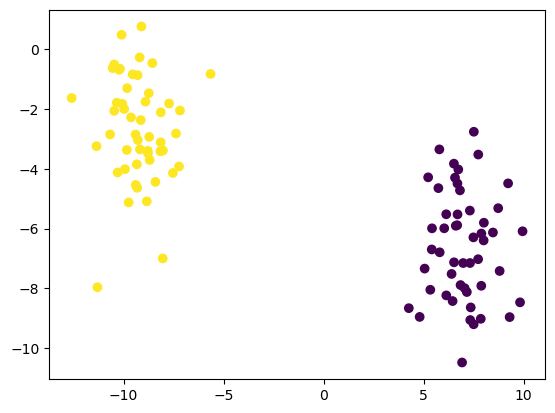

In [4]:
from sklearn.datasets import make_blobs
from sklearn import model_selection as ms
from numpy import float32
from matplotlib.pyplot import scatter, show, subplots
import cv2

# Generate a dataset of 2D data points and their ground truth labels
x, y_true = make_blobs(n_samples=100, centers=2, cluster_std=1.5, random_state=2)

# Plot the dataset
scatter(x[:, 0], x[:, 1], c=y_true)
show()

### The Code Output

The code above should generate the following plot of data points.

#### Explanation of the Output
- The plot will show two groups of points, representing the two classes generated by `make_blobs`.
- This visual illustrates if the data points are **linearly separable**, meaning they can be divided by a straight line.
- This concept is key for SVMs, which aim to find a hyperplane (line in 2D) that best separates the two classes.

#### Use of the Output
- **Model Training:** This dataset can train an SVM classifier, providing a simple example for understanding concepts like hyperplanes, margins, and support vectors.
- **Parameter Tuning:** The plot helps assess if a linear SVM is sufficient or if a kernel trick is needed.
- **Illustrative Example:** This setup visually demonstrates SVM concepts, making it ideal for learning before using more complex datasets.

This setup clarifies how an SVM would classify new points by finding the optimal hyperplane to separate the two clusters.


___

### Splitting the Dataset

The next step is to split the dataset into training and testing sets, where the former will be used to train the SVM and the latter to test it.

#### train_test_split
- This function from sklearn.model_selection splits arrays or matrices into random train and test subsets.
- **Parameters:**
  - x: Feature matrix containing input data.
  - y_true: Target array (labels) corresponding to the input data.
  - test_size=0.2: Specifies that 20% of the data is for testing, with 80% for training.
  - random_state=10: Ensures reproducibility by setting a random seed for consistent splits.

#### Plotting the Data
- **subplots(1, 2)**: Creates a figure with 1 row and 2 columns of subplots to display two datasets side by side.
- **Training Data Plot:**
  - ax1.scatter(...): Plots a scatter plot of the training data using x_train[:, 0] and x_train[:, 1].
  - c=y_train: Colors points based on labels in y_train.
  - ax1.set_title(...): Assigns a title to the training data subplot.
  
- **Testing Data Plot:**
  - ax2.scatter(...): Similar to the training plot but for testing data.
  - ax2.set_title(...): Assigns a title to the testing data subplot.

#### Displaying the Figure
- **show()**: Displays the figure containing both scatter plots.


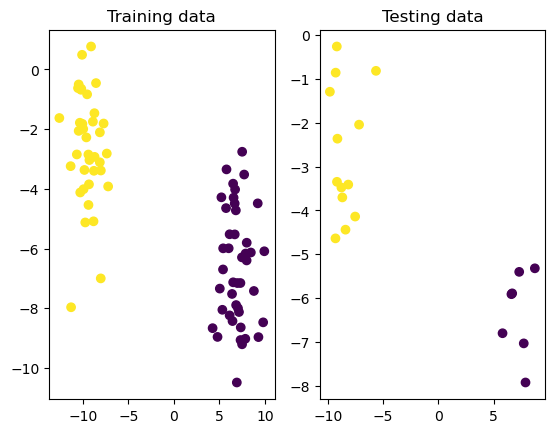

In [4]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = ms.train_test_split(x, y_true, test_size=0.2, random_state=10)

# Plot the training and testing datasets
fig, (ax1, ax2) = subplots(1, 2)
ax1.scatter(x_train[:, 0], x_train[:, 1], c=y_train)
ax1.set_title('Training data')
ax2.scatter(x_test[:, 0], x_test[:, 1], c=y_test)
ax2.set_title('Testing data')
show()

### Explanation of the Output

#### Visual Representation
- The scatter plots allow for a visual assessment of how well the features are distributed between training and testing datasets.
- Observing the density and spread of points can provide insights into the data's nature (e.g., linear separability or clustering).

#### Understanding Class Distribution
- The colors in both plots reveal how the classes (or labels) are distributed in each dataset.
- A balanced distribution is desirable for effective model training and evaluation.

### Use of the Output
- **Model Evaluation:** The split datasets are used to train models and evaluate their performance. The training set fits the model, while the testing set assesses generalization to unseen data.
  
- **Visual Diagnostics:** The plots can identify potential issues, such as:
  - Imbalanced classes (one class dominating).
  - Patterns or clusters informing feature engineering or model selection.
  
- **Reproducibility:** Using random_state ensures results can be reproduced, which is important in scientific contexts.

This code is crucial in the data preprocessing and exploratory analysis phase of a machine learning workflow.


### Training the Support Vector Machine (SVM)

From the training data image, it is evident that the two classes are easily separable by a straight line. We will now set up and train a Support Vector Machine (SVM) in OpenCV using a linear kernel to find the optimal dividing line.

#### ml.SVM_create()
- Initializes a new SVM model instance in OpenCV's machine learning module.
- Sets up the framework for creating an SVM but does not configure or train it yet.

#### svm.setKernel(ml.SVM_LINEAR)
- Configures the SVM to use a linear kernel.
- A linear kernel seeks a linear boundary to separate data points of different classes.
- Other kernel types, like polynomial or RBF, are available for non-linear separations, but a linear approach is simpler and effective when data is linearly separable.

#### svm.train(...)
- Trains the SVM model on the training dataset.
- x_train.astype(float32): Converts training features to float32, which some libraries require for numerical operations.
- ml.ROW_SAMPLE: Indicates that the training data is organized in rows, with each row representing a sample.
- y_train: The target labels corresponding to the training samples that the model will learn to predict.


In [5]:
# Create a new SVM using OpenCV
svm = cv2.ml.SVM_create()

# Set the SVM kernel to linear
svm.setKernel(cv2.ml.SVM_LINEAR)

# Train the SVM on the set of training data
svm.train(x_train.astype(float32), cv2.ml.ROW_SAMPLE, y_train)

True

**Note:** The SVM’s train method in OpenCV requires the input data to be of the 32-bit float type.

We now proceed to use the trained SVM to predict labels for the testing data and subsequently calculate the classifier’s accuracy by comparing the predictions with their corresponding ground truth.

- **svm.predict(...):** This method is used to make predictions using the trained SVM model.

- **x_test.astype(float32):** Converts the testing feature data to float32, ensuring it matches the data type used during training.

- The function returns two values, but we only need the predicted labels, which are stored in y_pred. The underscore (_) is used to ignore the first returned value, which often contains additional information (like distances to the hyperplane).

- **y_pred[:, 0].astype(int):** This extracts the first column of the y_pred array (predicted labels) and converts it to integers.

- **== y_test:** This comparison checks how many of the predicted labels match the actual labels in y_test, resulting in a boolean array (True for correct predictions and False for incorrect).

- **sum(...):** This function sums up the number of correct predictions (True values are treated as 1 and False as 0).

- **y_test.size:** This gets the total number of samples in the testing set, which is used to calculate accuracy.

- **\* 100:** Converts the accuracy into a percentage.


### Prediction

Given a new data point \( x \), the predicted class label \( y \) is:

$$
y = \text{sign}(w \cdot x + b)
$$

where:

- sign is the sign function, returning \( +1 \) for class 1 and \( -1 \) for class 0.


### Accuracy Calculation

Accuracy measures the proportion of correctly classified samples out of the total samples. It is calculated as:

$$
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}} \times 100
$$


In [6]:
# Predict the target labels of the testing data
_, y_pred = svm.predict(x_test.astype(float32))

# Compute and print the achieved accuracy
accuracy = (sum(y_pred[:, 0].astype(int) == y_test) / y_test.size) * 100
print('Accuracy:', accuracy, '%')


Accuracy: 100.0 %


### Explanation of the Output

- **Accuracy Value:** The accuracy percentage indicates the proportion of correct predictions made by the SVM model on the test dataset. A higher accuracy means that the model successfully classified more of the test samples.

#### Interpretation:
- If the accuracy is high (e.g., above 80-90%), it suggests that the SVM model is effectively distinguishing between the two classes in the dataset.
- If the accuracy is low, it may indicate that the model is not performing well, possibly due to overfitting, underfitting, or a poor choice of features.

### Use of the Output

- **Model Evaluation:** The accuracy metric is crucial for assessing how well the model has learned from the training data and can generalize to new, unseen data.
  
- **Comparative Analysis:** Accuracy allows for comparisons between different models or algorithms. If you try other models or parameters, you can use accuracy to see which one performs better.

- **Decision Making:** Depending on the achieved accuracy, you may decide to further tune the model, gather more data, or adjust the features used to improve performance.


### Explanation of Grid Creation

- **meshgrid(...):** This function creates a rectangular grid from two given one-dimensional arrays (for the x and y coordinates).
  
- **arange(...):** Generates a range of values. 
  - The first call to `arange` creates a range of x values that extend from the minimum x value of x_test minus 1 to the maximum x value of x_test plus 1, with a step size of 0.05.
  - The second call does the same for the y values.
  
- **Output:** The resulting x_bound and y_bound will be 2D arrays representing all combinations of the specified x and y values.

### Data Preparation for Predictions

- **reshape(-1, 1):** Converts the 2D arrays x_bound and y_bound into column vectors, making them suitable for stacking.

- **column_stack(...):** Stacks the two column vectors (x and y coordinates) horizontally to form an array of shape (N, 2), where N is the total number of grid points.

- **astype(float32):** Converts the data type of the resulting array to float32 for compatibility with the SVM model.

- **svm.predict(bound_points):** Uses the trained SVM model to predict the class labels for each point in bound_points. The predictions are stored in bound_pred, indicating which class each point belongs to.


In [7]:
from numpy import float32, meshgrid, arange, column_stack
from matplotlib.pyplot import scatter, show, contourf, cm
 
 
x_bound, y_bound = meshgrid(arange(x_test[:, 0].min() - 1, x_test[:, 0].max() + 1, 0.05),
                            arange(x_test[:, 1].min() - 1, x_test[:, 1].max() + 1, 0.05))
 
bound_points = column_stack((x_bound.reshape(-1, 1), y_bound.reshape(-1, 1))).astype(float32)
_, bound_pred = svm.predict(bound_points)

## Visualizing SVM Decision Boundary with Testing Data Points

We can create a contour plot that shows the decision boundary created by the SVM and add the testing data points on top. This visualization helps us assess if the SVM's decision boundary is indeed linear.

### Explanation of Functions and Parameters

- **contourf(...)**: This function from `matplotlib.pyplot` creates filled contour plots, helping to visualize the decision boundary based on predicted class labels for the grid of points.
  - **Parameters**:
    - **x_bound**: The x-coordinates of the grid points.
    - **y_bound**: The y-coordinates of the grid points.
    - **bound_pred.reshape(x_bound.shape)**: Reshapes the bound_pred array (containing the predicted labels) to match the shape of x_bound for proper visualization. Each unique label will fill a region of the plot according to the predicted class.
    - **cmap=cm.coolwarm**: Specifies the colormap used for coloring the regions. The `coolwarm` colormap provides a gradient, aiding in visualizing the class separation.

- **scatter(...)**: This function creates a scatter plot for the testing data points.
  - **Parameters**:
    - **x_test[:, 0]**: The x-coordinates of the testing data points.
    - **x_test[:, 1]**: The y-coordinates of the testing data points.
    - **c=y_test**: Colors the points based on their true labels from the testing dataset, allowing us to see how well the model's predictions align with the actual classes.


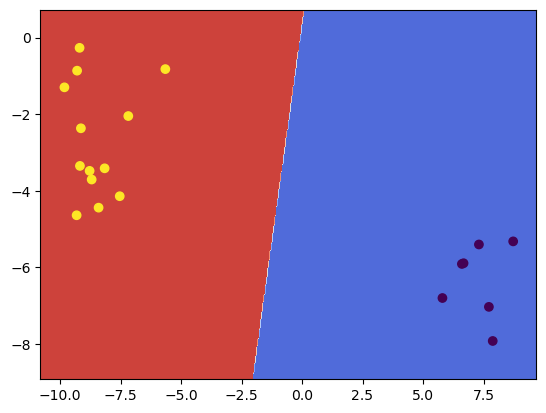

In [8]:
# Plot the testing set
contourf(x_bound, y_bound, bound_pred.reshape(x_bound.shape), cmap=cm.coolwarm)
scatter(x_test[:, 0], x_test[:, 1], c=y_test)
show()


### Explanation of the Output

**Contour Plot:**
- The filled contours represent the regions in the feature space where the SVM has predicted each class.
- The boundaries between different colors indicate where the model has decided that the class changes.
- If the SVM has learned well, there should be a clear separation between the colors that correspond to the two classes.
- Areas with a single color indicate regions where the SVM is confident about its predictions.

**Testing Data Points:**
- The scatter plot overlays the actual testing data points on top of the contour plot.
- By comparing the colors of the scatter points with the contour colors, you can assess how well the SVM model has performed:
  - If most points are correctly colored (i.e., match the color of the region they fall into), the model is performing well.
  - If there are many points in regions of incorrect color, it suggests that the model has misclassified those points.

### Use of the Output
- **Visualizing Decision Boundary:** The combined plots allow for a clear visualization of the decision boundary created by the SVM. This helps in understanding how the model interprets the feature space.
- **Model Evaluation:** By overlaying the test points, you can visually evaluate the model's performance, identify misclassified points, and ascertain the robustness of the decision boundary.
- **Communication of Results:** Such visualizations are useful for communicating findings to stakeholders or in reports, making it easier to understand how the model operates and its effectiveness.


___

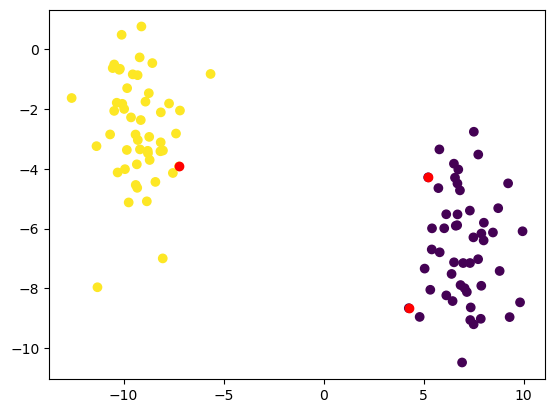

In [9]:
 
support_vect = svm.getUncompressedSupportVectors()
 
scatter(x[:, 0], x[:, 1], c=y_true)
scatter(support_vect[:, 0], support_vect[:, 1], c='red')
show()

### Explanation of the Output

**Scatter Plot of the Original Data:**
- This plot shows the distribution of the original data points, with different colors representing the two classes.

**Highlighted Support Vectors:**
- The red points on the plot represent the support vectors. These are the points closest to the decision boundary created by the SVM.
- By examining this visualization, you can see which data points are influencing the model's decision boundary.

### Use of the Output

- **Understanding Model Behavior:** Highlighting the support vectors helps illustrate which data points are critical for defining the decision boundary. It shows that only a subset of the data is necessary to determine the SVM's performance.
- **Model Evaluation:** Visualizing support vectors can help evaluate whether the model has effectively captured the relevant features of the dataset. If the support vectors are well-distributed, it suggests a robust decision boundary.
- **Explaining SVM Functionality:** This visualization is also useful for explaining how SVMs work to others, as it demonstrates the concept of support vectors in a clear and intuitive way.


So far, we've looked at simple cases with two clearly separated classes. But what about when the classes mix together and are harder to tell apart? In these situations, the decision boundary can get tricky. We need to use more advanced techniques to find ways to separate the classes effectively.


**getUncompressedSupportVectors():** This method retrieves the support vectors from the trained SVM model. Support vectors are the data points that are closest to the decision boundary and play a critical role in defining it. These points are essential for the SVM's performance and directly influence the position of the decision boundary.

**scatter(...):** This function from matplotlib.pyplot creates a scatter plot of the entire dataset (x).
- **x[:, 0]:** The x-coordinates of the data points.
- **x[:, 1]:** The y-coordinates of the data points.
- **c=y_true:** Colors the points based on their true labels (y_true), allowing you to see the distribution of the original classes.

**scatter(...):** This function is called again to plot the support vectors.
- **support_vect[:, 0]:** The x-coordinates of the support vectors.
- **support_vect[:, 1]:** The y-coordinates of the support vectors.
- **c='red':** Colors the support vectors red, making them stand out against the original data points.


In [10]:
# Generate a dataset of 2D data points and their ground truth labels
x, y_true = make_blobs(n_samples=100, centers=2, cluster_std=8, random_state=15)

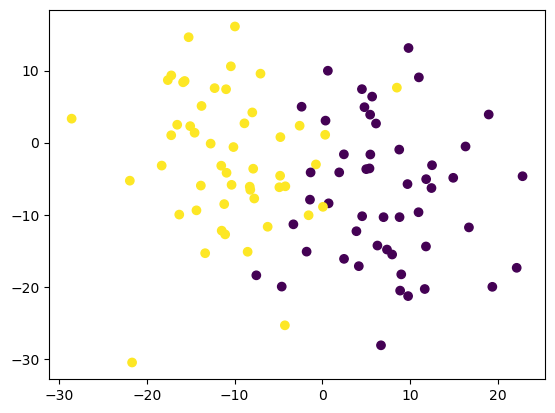

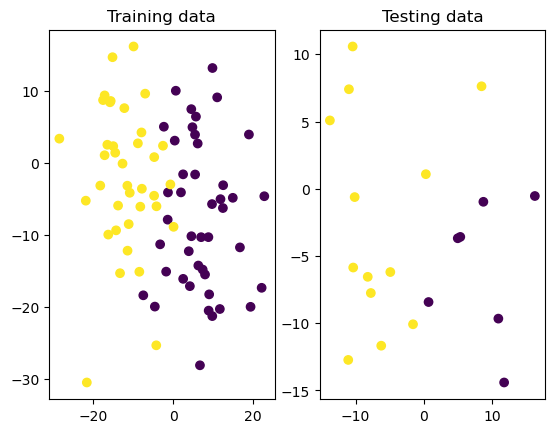

Accuracy: 75.0 %


In [11]:
# Plot the dataset
scatter(x[:, 0], x[:, 1], c=y_true)
show()

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = ms.train_test_split(x, y_true, test_size=0.2, random_state=10)

# Plot the training and testing datasets
fig, (ax1, ax2) = subplots(1, 2)
ax1.scatter(x_train[:, 0], x_train[:, 1], c=y_train)
ax1.set_title('Training data')
ax2.scatter(x_test[:, 0], x_test[:, 1], c=y_test)
ax2.set_title('Testing data')
show()

# Create a new SVM using OpenCV
svm = cv2.ml.SVM_create()

# Set the SVM kernel to linear
svm.setKernel(cv2.ml.SVM_LINEAR)

# Train the SVM on the set of training data
svm.train(x_train.astype(float32), cv2.ml.ROW_SAMPLE, y_train)

# Predict the target labels of the testing data
_, y_pred = svm.predict(x_test.astype(float32))

# Compute and print the achieved accuracy
accuracy = (sum(y_pred[:, 0].astype(int) == y_test) / y_test.size) * 100
print('Accuracy:', accuracy, '%')

In this case, we might want to try different approaches based on how much the two classes overlap. One option is to relax the margin constraint for the linear SVM by increasing the C parameter. This helps find a balance between maximizing the margin and reducing misclassifications. Another option is to use a different kernel function, like the Radial Basis Function (RBF), which can create a non-linear decision boundary.

To do this, we need to set a few properties of the SVM and the kernel:

- **SVM_C_SVC:** This type of SVM allows for multi-class classification, even when classes are not perfectly separated. We set this with the `setType` method.
- **C:** This is a penalty for misclassified points, especially when classes overlap. We set it using the `setC` method.
- **Gamma:** This controls the radius of the RBF kernel. A smaller gamma means a wider radius, which can capture similarities between distant points but might overfit. A larger gamma means a narrower radius, capturing only nearby points and possibly underfitting. We set it with the `setGamma` method.

The values for C and gamma can be chosen at random, but it's a good idea to test different values to see how they affect prediction accuracy. Using both of these methods, we can achieve an accuracy of 85%, but each method will create a different decision boundary.


**Using a linear kernel with a relaxed margin constraint:**


- **setKernel(ml.SVM_LINEAR):** This function sets the kernel type of the SVM to a linear kernel. A linear kernel is used when we assume that the data can be separated by a straight line (or hyperplane) in the feature space.
  - **Purpose:** By choosing a linear kernel, we are indicating that we believe the classes in our data can be separated by a linear decision boundary.

- **setType(ml.SVM_C_SVC):** This function sets the type of SVM to C-Support Vector Classification (C-SVC). This type allows for multi-class classification (more than two classes) and is suitable for datasets where the classes are not perfectly separable.
  - **Purpose:** By specifying C-SVC, we enable the SVM to handle cases where the data points from different classes may overlap or are not clearly separable.

- **setC(10):** This function sets the penalty parameter C of the SVM. The C parameter controls the trade-off between maximizing the margin and minimizing classification error. A higher value of C gives more importance to correctly classifying all training points, even if it means a smaller margin.
  - **Purpose:** By setting C to 10, we are emphasizing the importance of minimizing misclassifications at the cost of potentially reducing the margin. This is useful in cases where we want to ensure that most of the training points are classified correctly.


In [12]:
from numpy import float32, meshgrid, arange, column_stack
from matplotlib.pyplot import scatter, show, contourf, cm
import cv2

# Create and train the SVM model
svm = cv2.ml.SVM_create()
svm.setKernel(cv2.ml.SVM_LINEAR)
svm.setType(cv2.ml.SVM_C_SVC)
svm.setC(10)

### Explanation of the Output

- **No Immediate Output:** There will be no immediate output displayed on the screen when these functions are called. The functions merely set parameters for the SVM model.
- **Configured Model:** The SVM model is now configured with a linear kernel and set to C-SVC type, with the penalty parameter C set to 10. This means the model is ready to be trained on a dataset with these specifications.

### Use of the Output

- **Model Training:** Once these parameters are set, you can proceed to train the SVM on your dataset. The behavior of the model during training will reflect these settings.
- **Predicting with the Model:** After training, the SVM will classify new data points based on the linear decision boundary created with the configured parameters.
- **Performance Tuning:** By adjusting the C parameter and kernel type, you can explore different configurations to improve the model’s performance, particularly in handling overlapping classes.


___

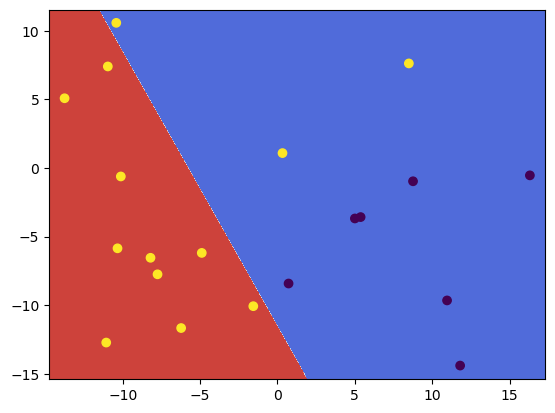

In [13]:

svm.train(x_train.astype(float32), cv2.ml.ROW_SAMPLE, y_train)

# Create meshgrid for decision boundary plotting
x_bound, y_bound = meshgrid(arange(x_test[:, 0].min() - 1, x_test[:, 0].max() + 1, 0.05),
                            arange(x_test[:, 1].min() - 1, x_test[:, 1].max() + 1, 0.05))

# Stack grid points for prediction
bound_points = column_stack((x_bound.reshape(-1,1), y_bound.reshape(-1,1))).astype(float32)

# Predict on the grid to get the decision boundary
_, bound_pred = svm.predict(bound_points)

# Plot the decision boundary with the test set points
contourf(x_bound, y_bound, bound_pred.reshape(x_bound.shape), cmap=cm.coolwarm)
scatter(x_test[:, 0], x_test[:, 1], c=y_test)
show()


**Using an RBF kernel function:**

- **setKernel(ml.SVM_RBF):** This function sets the kernel type of the SVM to the Radial Basis Function (RBF) kernel. The RBF kernel is useful for capturing non-linear relationships in the data, making it a popular choice for datasets where the classes are not linearly separable.
  - **Purpose:** By choosing the RBF kernel, we allow the SVM to create complex, curved decision boundaries that can better separate overlapping classes.

- **setC(10):** This function sets the penalty parameter C of the SVM to 10. The C parameter influences the trade-off between maximizing the margin and minimizing misclassifications. A higher value of C places greater emphasis on correctly classifying all training data points, potentially at the cost of a smaller margin.
  - **Purpose:** By setting C to 10, we prioritize minimizing misclassifications, which is important when the classes are not clearly distinguishable.

- **setGamma(0.1):** This function sets the gamma parameter for the RBF kernel. Gamma determines the influence of a single training example. A low gamma value (like 0.1) means that each training example has a wider influence, which can capture broader patterns in the data but may lead to overfitting. Conversely, a high gamma value results in a narrower influence, focusing more on local patterns, which can lead to underfitting.
  - **Purpose:** By setting gamma to 0.1, we aim for a balance where the model captures sufficient complexity in the data without overfitting too much.


### SVM Objective Function

In the training of an SVM with a linear or RBF (Radial Basis Function) kernel, the primary objective function is:

$$
\min_{w, b} \quad \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{N} \max\left(0, 1 - y_i (w \cdot x_i + b)\right)
$$


### RBF Kernel Transformation (when setKernel(ml.SVM_RBF))

For non-linearly separable data, an SVM can use a Radial Basis Function (RBF) kernel to map data to a higher-dimensional space where a linear decision boundary may be found. The RBF kernel function is:

$$
K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2 \right)
$$

In [14]:
from numpy import float32, meshgrid, arange, column_stack
from matplotlib.pyplot import scatter, show, contourf, cm
import cv2

# Create and train the SVM model with RBF kernel
svm = cv2.ml.SVM_create()
svm.setKernel(cv2.ml.SVM_RBF)  # Use RBF kernel
svm.setType(cv2.ml.SVM_C_SVC)
svm.setC(10)  # Set C parameter
svm.setGamma(0.1)  # Set gamma parameter

### Explanation of the Output

- **No Immediate Output:** There will be no immediate output displayed on the screen. These functions simply set the parameters for the SVM model.
- **Configured Model:** After executing these lines, the SVM model is configured to use the RBF kernel, set as C-SVC type, with a penalty parameter C of 10 and gamma set to 0.1. This configuration prepares the model to effectively handle datasets with non-linear relationships.

### Use of the Output

- **Model Training:** Once these parameters are set, the SVM can be trained on a dataset. The behavior of the model during training will reflect the chosen kernel and parameter settings.
- **Prediction with the Model:** After training, the SVM will classify new data points based on the non-linear decision boundary created with the configured parameters.
- **Performance Tuning:** Adjusting the values of C and gamma allows exploration of how different configurations affect model performance, particularly in scenarios where classes overlap.


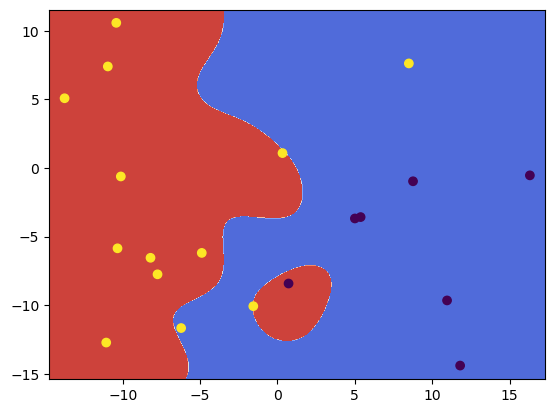

In [15]:
svm.train(x_train.astype(float32), cv2.ml.ROW_SAMPLE, y_train)

# Create meshgrid for decision boundary plotting
x_bound, y_bound = meshgrid(arange(x_test[:, 0].min() - 1, x_test[:, 0].max() + 1, 0.05),
                            arange(x_test[:, 1].min() - 1, x_test[:, 1].max() + 1, 0.05))

# Stack grid points for prediction
bound_points = column_stack((x_bound.ravel(), y_bound.ravel())).astype(float32)

# Predict on the grid to get the decision boundary
_, bound_pred = svm.predict(bound_points)

# Plot the decision boundary with the test set points
contourf(x_bound, y_bound, bound_pred.reshape(x_bound.shape), cmap=cm.coolwarm)
scatter(x_test[:, 0], x_test[:, 1], c=y_test)
show()
